In [1]:
from pathlib import Path
import re
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path().resolve().parents[1]
print(f"Project root: {ROOT}")

Project root: /Users/itsuki/Adaptive-Testing-Based-on-Reinforcement-Learning-Considering-Response-History


In [2]:
# ---- 設定 ----------------------------------------------------------------
bank_id = 1
prior   = "normal"

results_dir = ROOT / "EXP014" / "results"

# 存在する全 gamma の train_log を収集
pattern = re.compile(rf"train_log_{prior}_uncor_{bank_id}_gamma_(.+)\.csv")
gamma_files = {
    pattern.match(p.name).group(1): p
    for p in sorted(results_dir.glob(f"train_log_{prior}_uncor_{bank_id}_gamma_*.csv"))
    if pattern.match(p.name)
}

print(f"Found gamma values: {list(gamma_files.keys())}")

Found gamma values: ['0.1']


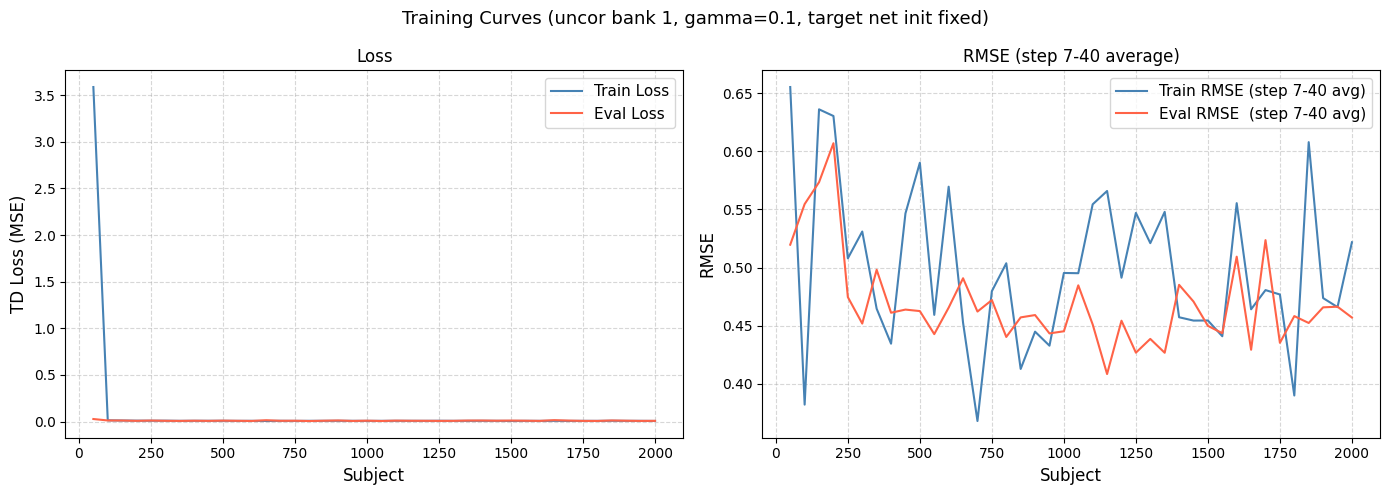

Saved to /Users/itsuki/Adaptive-Testing-Based-on-Reinforcement-Learning-Considering-Response-History/EXP014/results/train_log_uncor_1_gamma_0.1.png


In [3]:
out_dir = results_dir
out_dir.mkdir(parents=True, exist_ok=True)

for gamma, path in gamma_files.items():
    log = pd.read_csv(path)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(
        f"Training Curves (uncor bank {bank_id}, gamma={gamma}, target net init fixed)",
        fontsize=13,
    )

    # ---- Loss ----
    ax = axes[0]
    ax.plot(log["subject"], log["train_loss"], label="Train Loss", color="steelblue", linewidth=1.5)
    ax.plot(log["subject"], log["eval_loss"],  label="Eval Loss",  color="tomato",    linewidth=1.5)
    ax.set_xlabel("Subject", fontsize=12)
    ax.set_ylabel("TD Loss (MSE)", fontsize=12)
    ax.set_title("Loss", fontsize=12)
    ax.legend(fontsize=11)
    ax.grid(True, linestyle="--", alpha=0.5)

    # ---- RMSE ----
    ax = axes[1]
    ax.plot(log["subject"], log["train_rmse"], label="Train RMSE (step 7-40 avg)", color="steelblue", linewidth=1.5)
    ax.plot(log["subject"], log["eval_rmse"],  label="Eval RMSE  (step 7-40 avg)", color="tomato",    linewidth=1.5)
    ax.set_xlabel("Subject", fontsize=12)
    ax.set_ylabel("RMSE", fontsize=12)
    ax.set_title("RMSE (step 7-40 average)", fontsize=12)
    ax.legend(fontsize=11)
    ax.grid(True, linestyle="--", alpha=0.5)

    plt.tight_layout()

    out_path = out_dir / f"train_log_uncor_{bank_id}_gamma_{gamma}.png"
    fig.savefig(out_path, dpi=150)
    plt.show()
    print(f"Saved to {out_path}")